In [1]:
import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import numpy as np
import feos
import si_units as si
import matplotlib.pyplot as plt
import thermoift.FeosPlugin as TC
import thermoift.semi_emperical_correlations as SEC
import thermoift.PLOT_SETTINGS as ps

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=b52093bd63e815394d911e9b1ef9d730810efd1c8ffe42b084b46c9e0e14986d
  Stored in directory: /tmp/pip-ephem-wheel-cache-9psaljxf/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
COMPONENT_NAMES = ["carbon dioxide", "hydrogen", "argon"]
FEED_Z          = np.array([0.95, 0.02, 0.03], dtype=float)
FEED_Z          = FEED_Z / FEED_Z.sum()

In [3]:
params          = TC.PARAMETERS(COMPONENT_NAMES)
eos             = feos.HelmholtzEnergyFunctional.pcsaft(params)
feed_si         = FEED_Z * si.MOL
Tc_si, Pc_si    = TC.VLECalculator.compute_critical_point(eos, FEED_Z, T_guess=300.0)
Tc_K            = Tc_si / si.KELVIN
Pc_bar          = Pc_si / si.BAR
T_vals          = np.linspace(200.0, Tc_K , 500)
T_bub, P_bub    = TC.VLECalculator.compute_bubble_curve(eos, T_vals, feed_si, verbose=False)
T_dew, P_dew    = TC.VLECalculator.compute_dew_curve(eos, T_vals, feed_si, verbose=False)

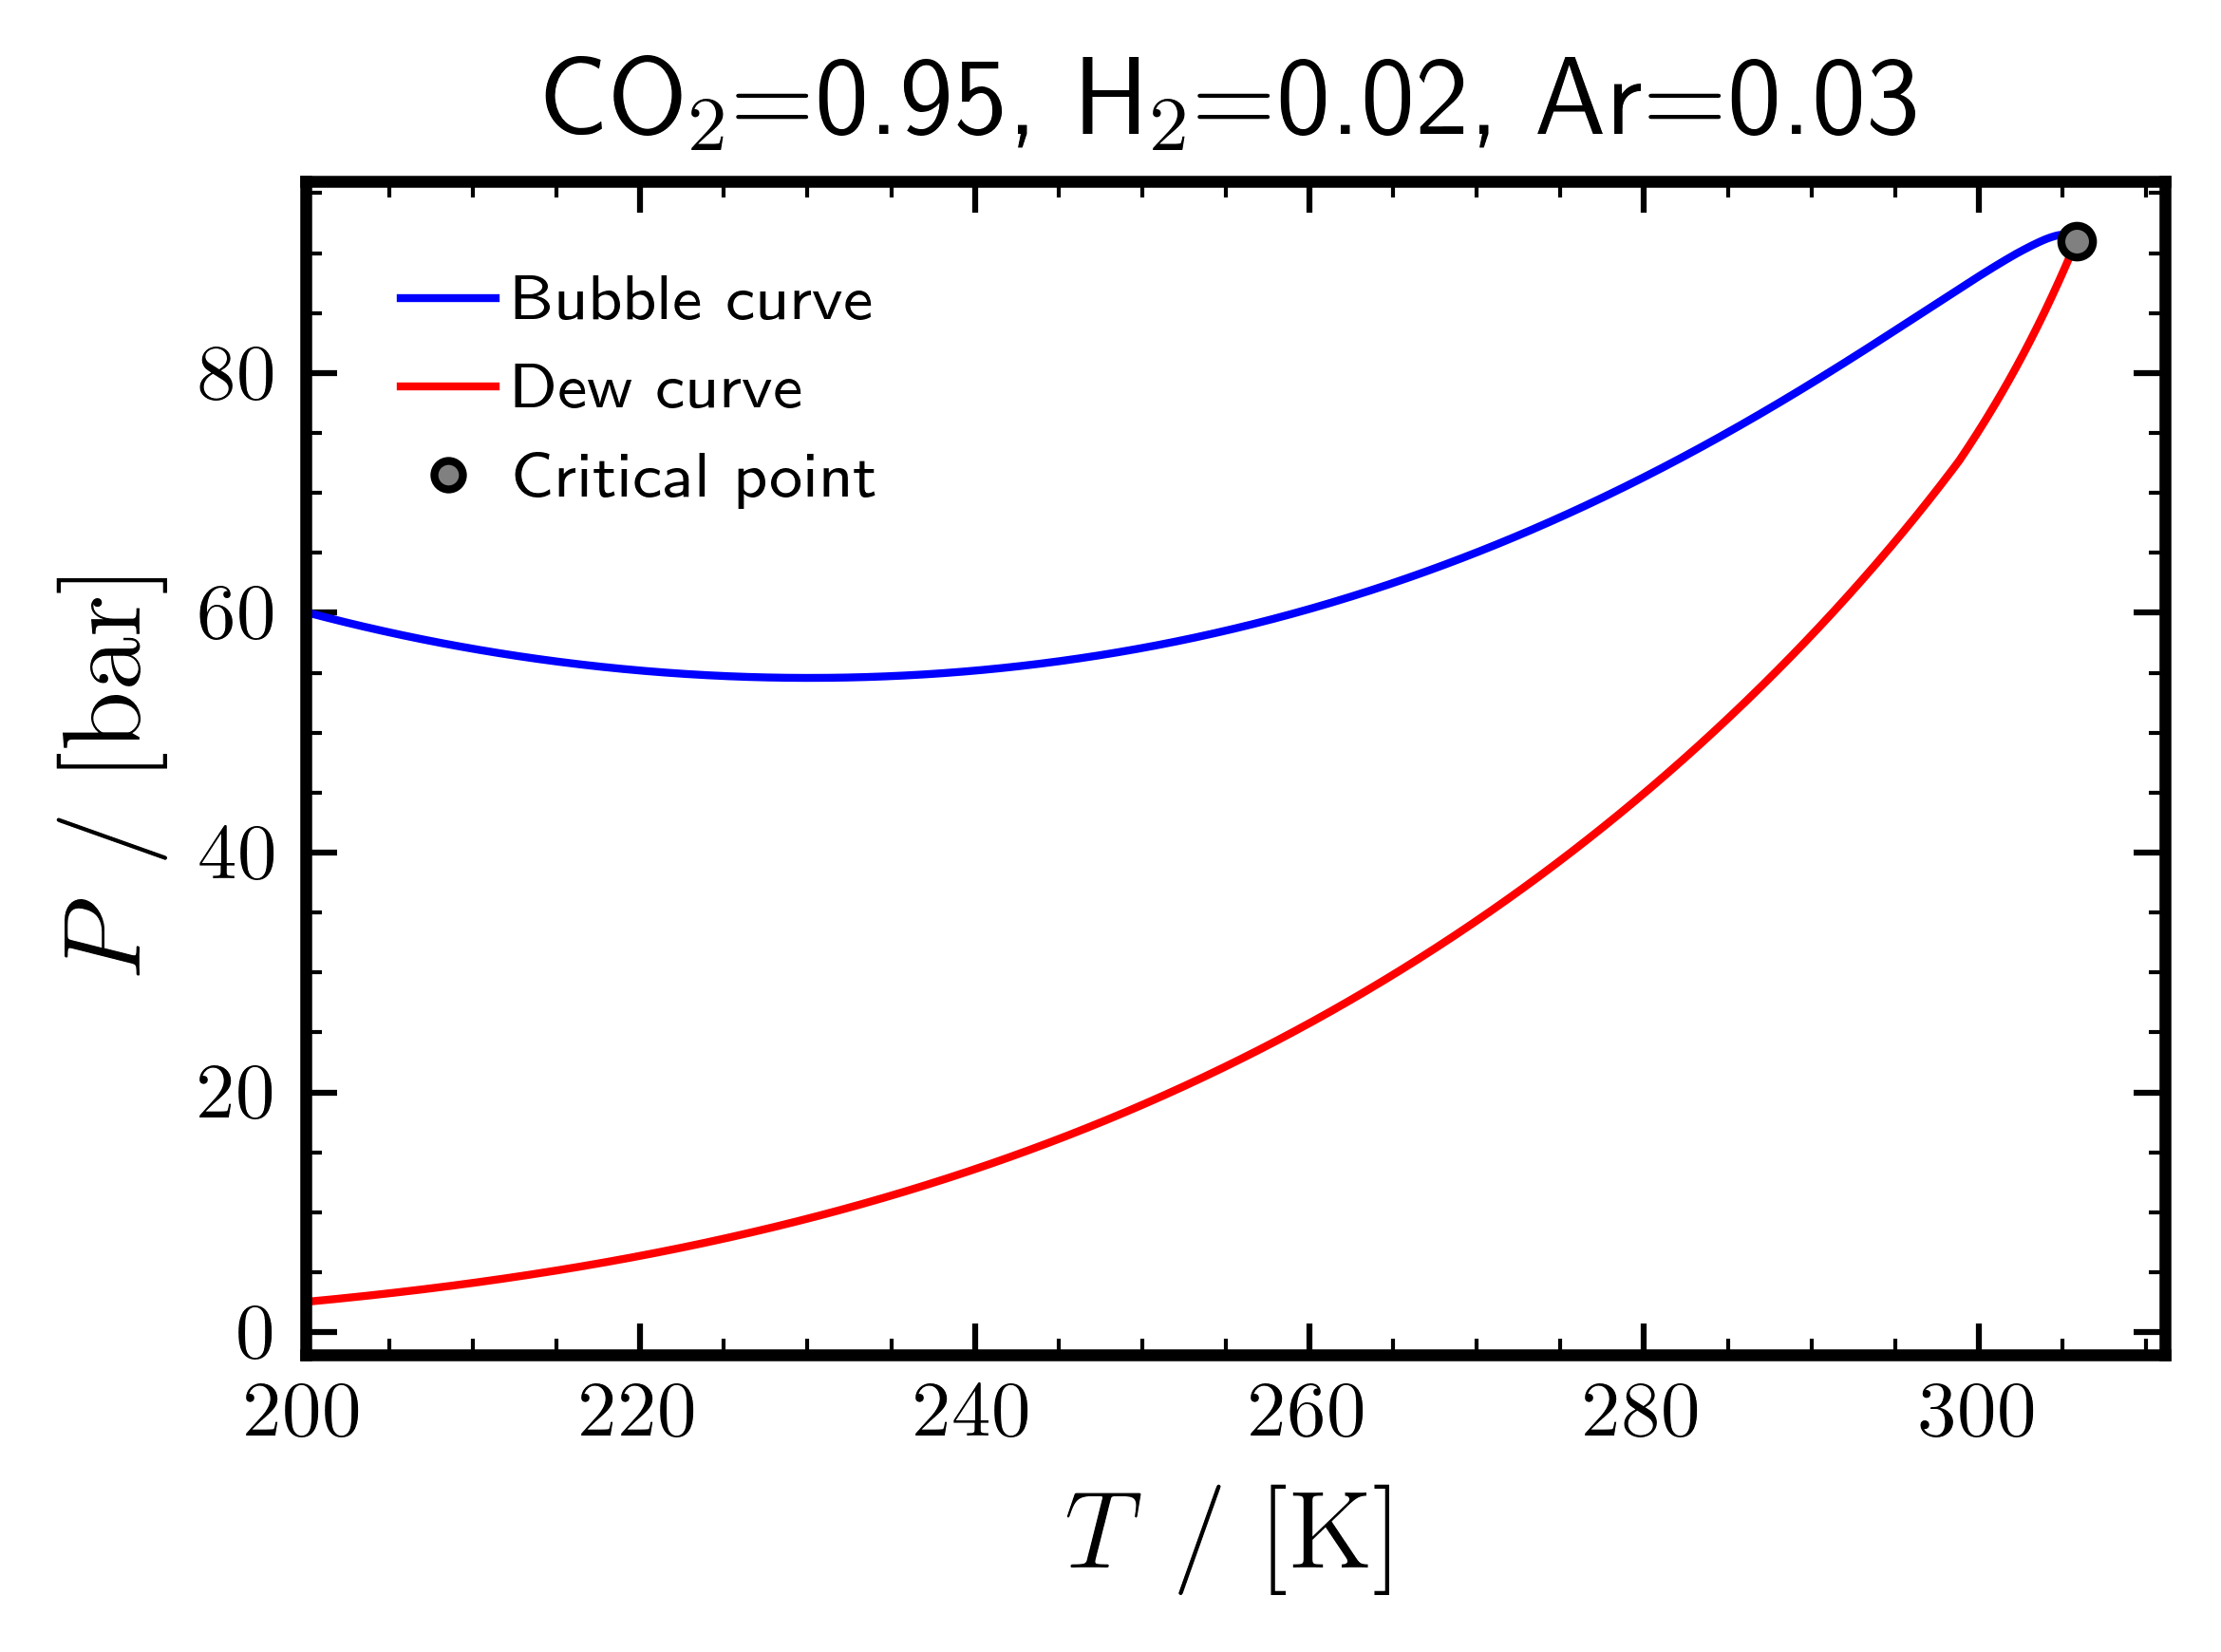

In [4]:
# Build PT_results dict in the format expected by PlottingEngine
feed_key = "feed_0"
PT_results = {
    feed_key: {
        "bubble": [{"T_K": T, "P_bar": P} for T, P in zip(T_bub, P_bub)],
        "dew": [{"T_K": T, "P_bar": P} for T, P in zip(T_dew, P_dew)],
        "TC_K": Tc_K,
        "PC_bar": Pc_bar,
        "z": FEED_Z,
    }
}

# Plot using PlottingEngine
fig, ax = TC.PlottingEngine.plot_phase_diagram(PT_results, feed_key, params)
plt.show()

In [5]:
# -------------------------------------------------------------------------------------------
# Compute IFT along saturation lines only (bubble & dew curves) - for metastable computations
# -------------------------------------------------------------------------------------------

# Compute IFT only at bubble and dew points Parachor method (T-dependent)
model = SEC.semi_emperical_correlations()

# Use n_points to control number of T grid points (faster with fewer points)
# Use P_offset_frac to stay slightly inside two-phase region for reliable TP flash
N_POINTS = 50  # Use 50 T points instead of all 500

sat_data_parachor = model.compute_saturation_line_IFT(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="parachor",
    n_exp=3.87,
    kij_parachor=0.0,
    recompute_parachor=True,
    line="both",
    n_points=N_POINTS,        # Use coarser T grid for speed
    P_offset_frac=0.005,      # 0.5% offset to stay inside two-phase region
)

# WSD method along saturation lines
sat_data_wsd = model.compute_saturation_line_IFT(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="wsd",
    phi_wsd=1.0,
    wsd_correction=True,
    line="both",
    n_points=N_POINTS,
    P_offset_frac=0.005,
)

# Convert to DataFrames
df_sat_parachor = SEC.semi_emperical_correlations.saturation_line_to_dataframe(
    sat_data_parachor, COMPONENT_NAMES, line="both")

df_sat_wsd = SEC.semi_emperical_correlations.saturation_line_to_dataframe(
    sat_data_wsd, COMPONENT_NAMES, line="both")

print(f"Parachor DataFrame shape: {df_sat_parachor.shape}")
print(f"WSD DataFrame shape: {df_sat_wsd.shape}")

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:175: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300.61397145980027 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:175: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=302.7546942568173 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:175: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=304.8954170538343 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:175: UserWarning: cDF

Parachor DataFrame shape: (100, 33)
WSD DataFrame shape: (96, 33)


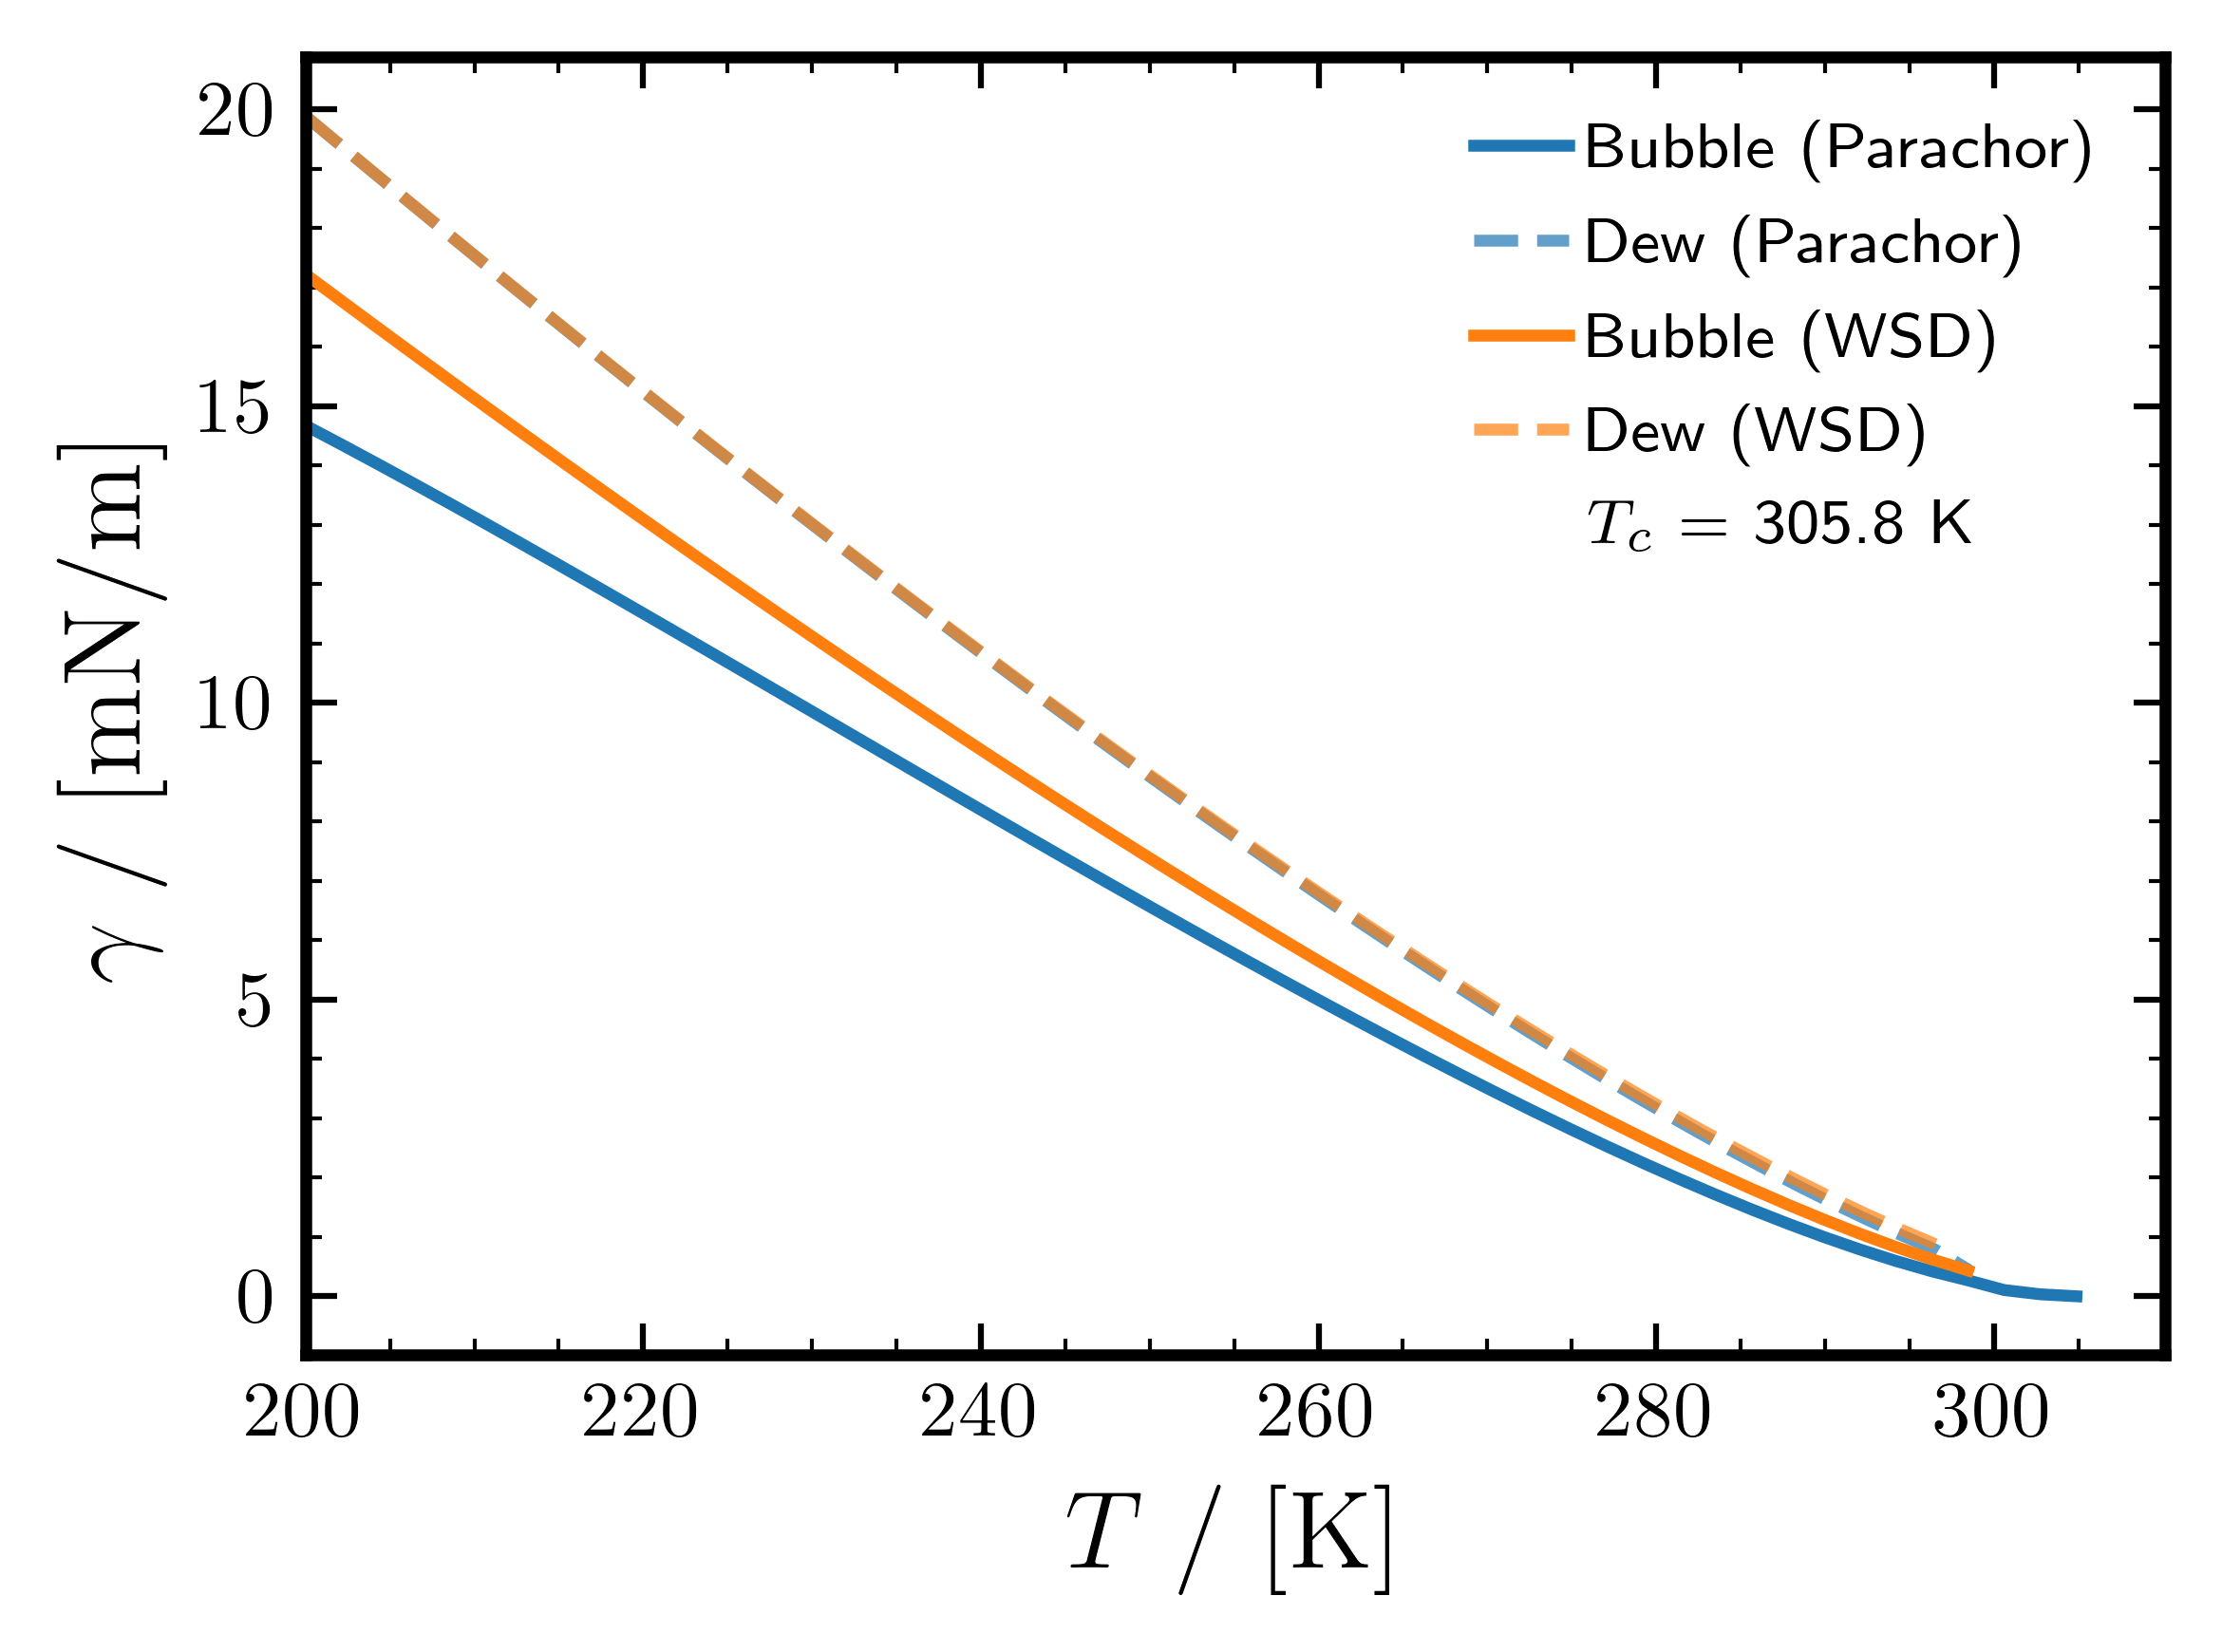

In [13]:
# --- Plot 1: IFT vs Temperature ---
if df_sat_parachor.empty and df_sat_wsd.empty:
    print("No data available - both DataFrames are empty")
else:
    fig, ax = ps.plot_init()

    # Parachor
    if not df_sat_parachor.empty and "line" in df_sat_parachor.columns:
        bub_para = df_sat_parachor[df_sat_parachor["line"] == "bubble"]
        dew_para = df_sat_parachor[df_sat_parachor["line"] == "dew"]

        if not bub_para.empty:
            ax.plot(
                bub_para["T"], bub_para["gamma_mix"],
                "-", label="Bubble (Parachor)", color="C0"
            )
        if not dew_para.empty:
            ax.plot(
                dew_para["T"], dew_para["gamma_mix"],
                "--", label="Dew (Parachor)", color="C0", alpha=0.7
            )
    else:
        bub_para, dew_para = None, None

    # WSD
    if not df_sat_wsd.empty and "line" in df_sat_wsd.columns:
        bub_wsd = df_sat_wsd[df_sat_wsd["line"] == "bubble"]
        dew_wsd = df_sat_wsd[df_sat_wsd["line"] == "dew"]

        if not bub_wsd.empty:
            ax.plot(
                bub_wsd["T"], bub_wsd["gamma_mix"],
                "-", label="Bubble (WSD)", color="C1"
            )
        if not dew_wsd.empty:
            ax.plot(
                dew_wsd["T"], dew_wsd["gamma_mix"],
                "--", label="Dew (WSD)", color="C1", alpha=0.7
            )
    else:
        bub_wsd, dew_wsd = None, None

    ax.axvline(Tc_K, color="w", linestyle=":", label=f"$T_c$ = {Tc_K:.1f} K")
    ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$", fontsize=ps.label_fontsize)
    ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
    ax.set_xlim(left=200)
    ax.minorticks_on()
    ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
    plt.tight_layout()
    plt.show()

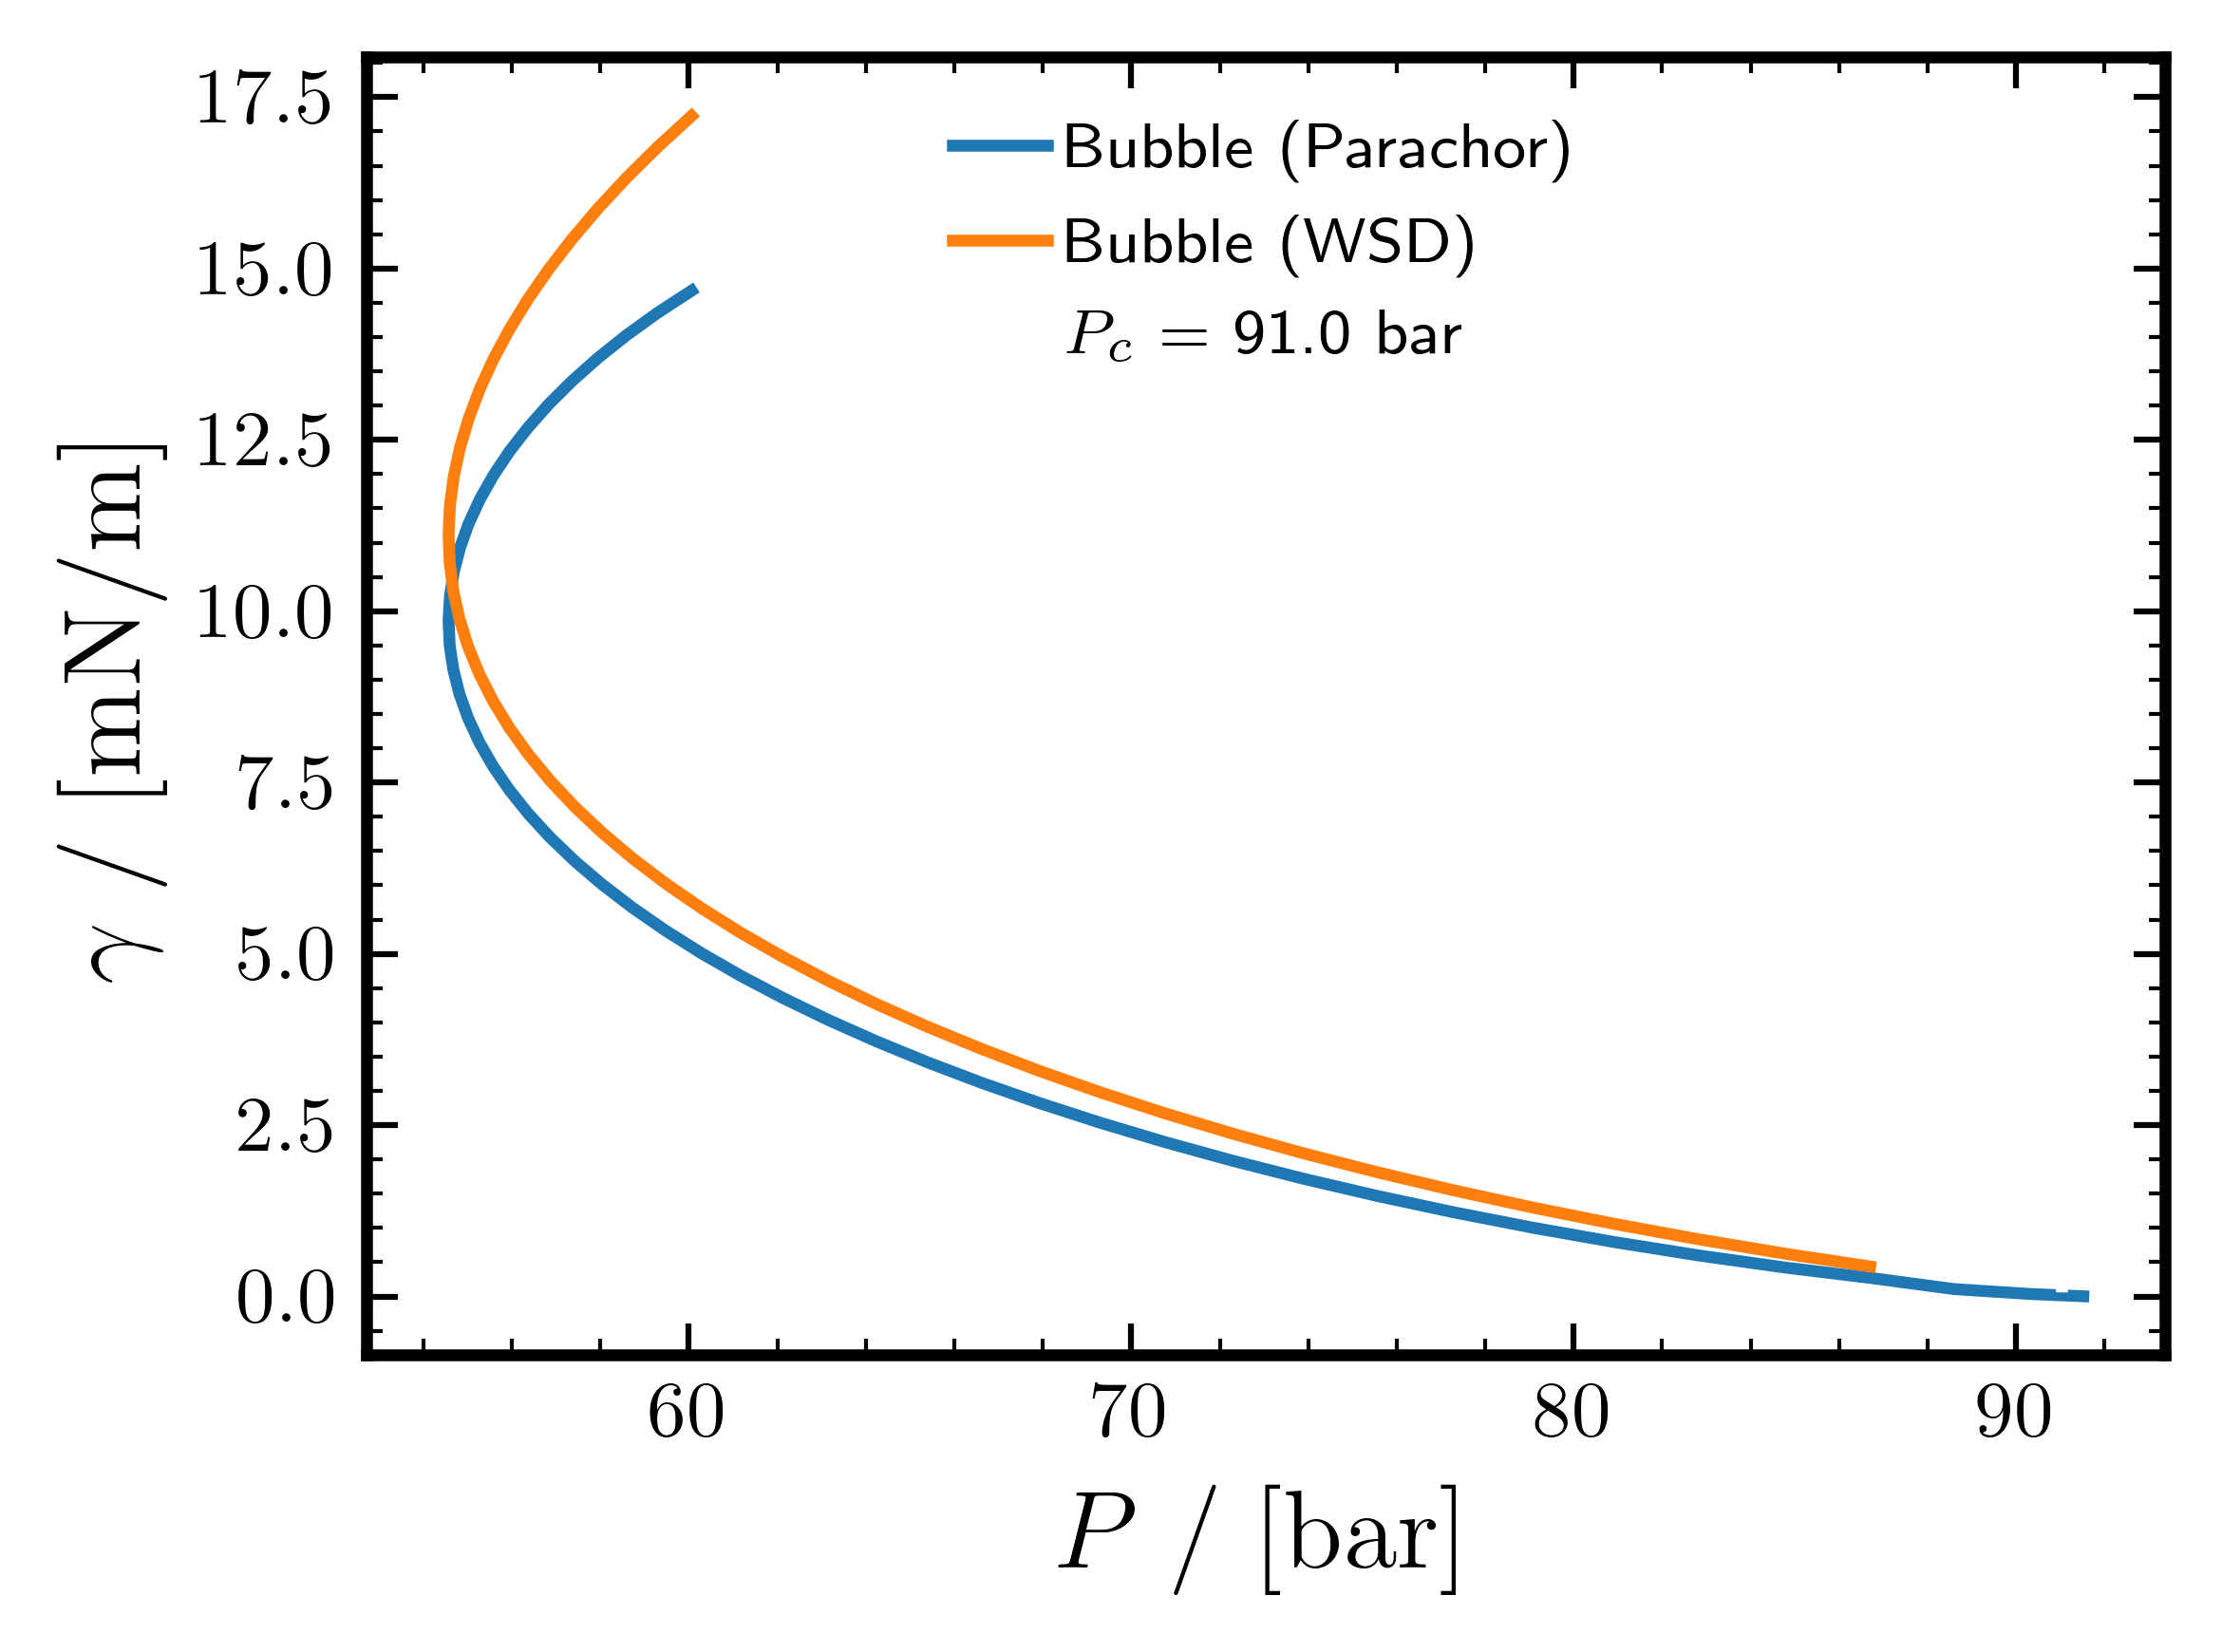

In [16]:
# --- Plot 2: IFT vs Pressure ---
if df_sat_parachor.empty and df_sat_wsd.empty:
    print("No data available - both DataFrames are empty")
else:
    fig, ax = ps.plot_init()

    if bub_para is not None and not bub_para.empty:
        ax.plot(
            bub_para["P"], bub_para["gamma_mix"],
            "-", label="Bubble (Parachor)", color="C0")

    if bub_wsd is not None and not bub_wsd.empty:
        ax.plot(
            bub_wsd["P"], bub_wsd["gamma_mix"],
            "-", label="Bubble (WSD)", color="C1"
        )

    ax.axvline(Pc_bar, color="w", linestyle=":", label=f"$P_c$ = {Pc_bar:.1f} bar")
    ax.set_xlabel(r"$P \; / \; [\mathrm{bar}]$", fontsize=ps.label_fontsize)
    ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
    ax.minorticks_on()
    ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
    plt.tight_layout()
    plt.show()

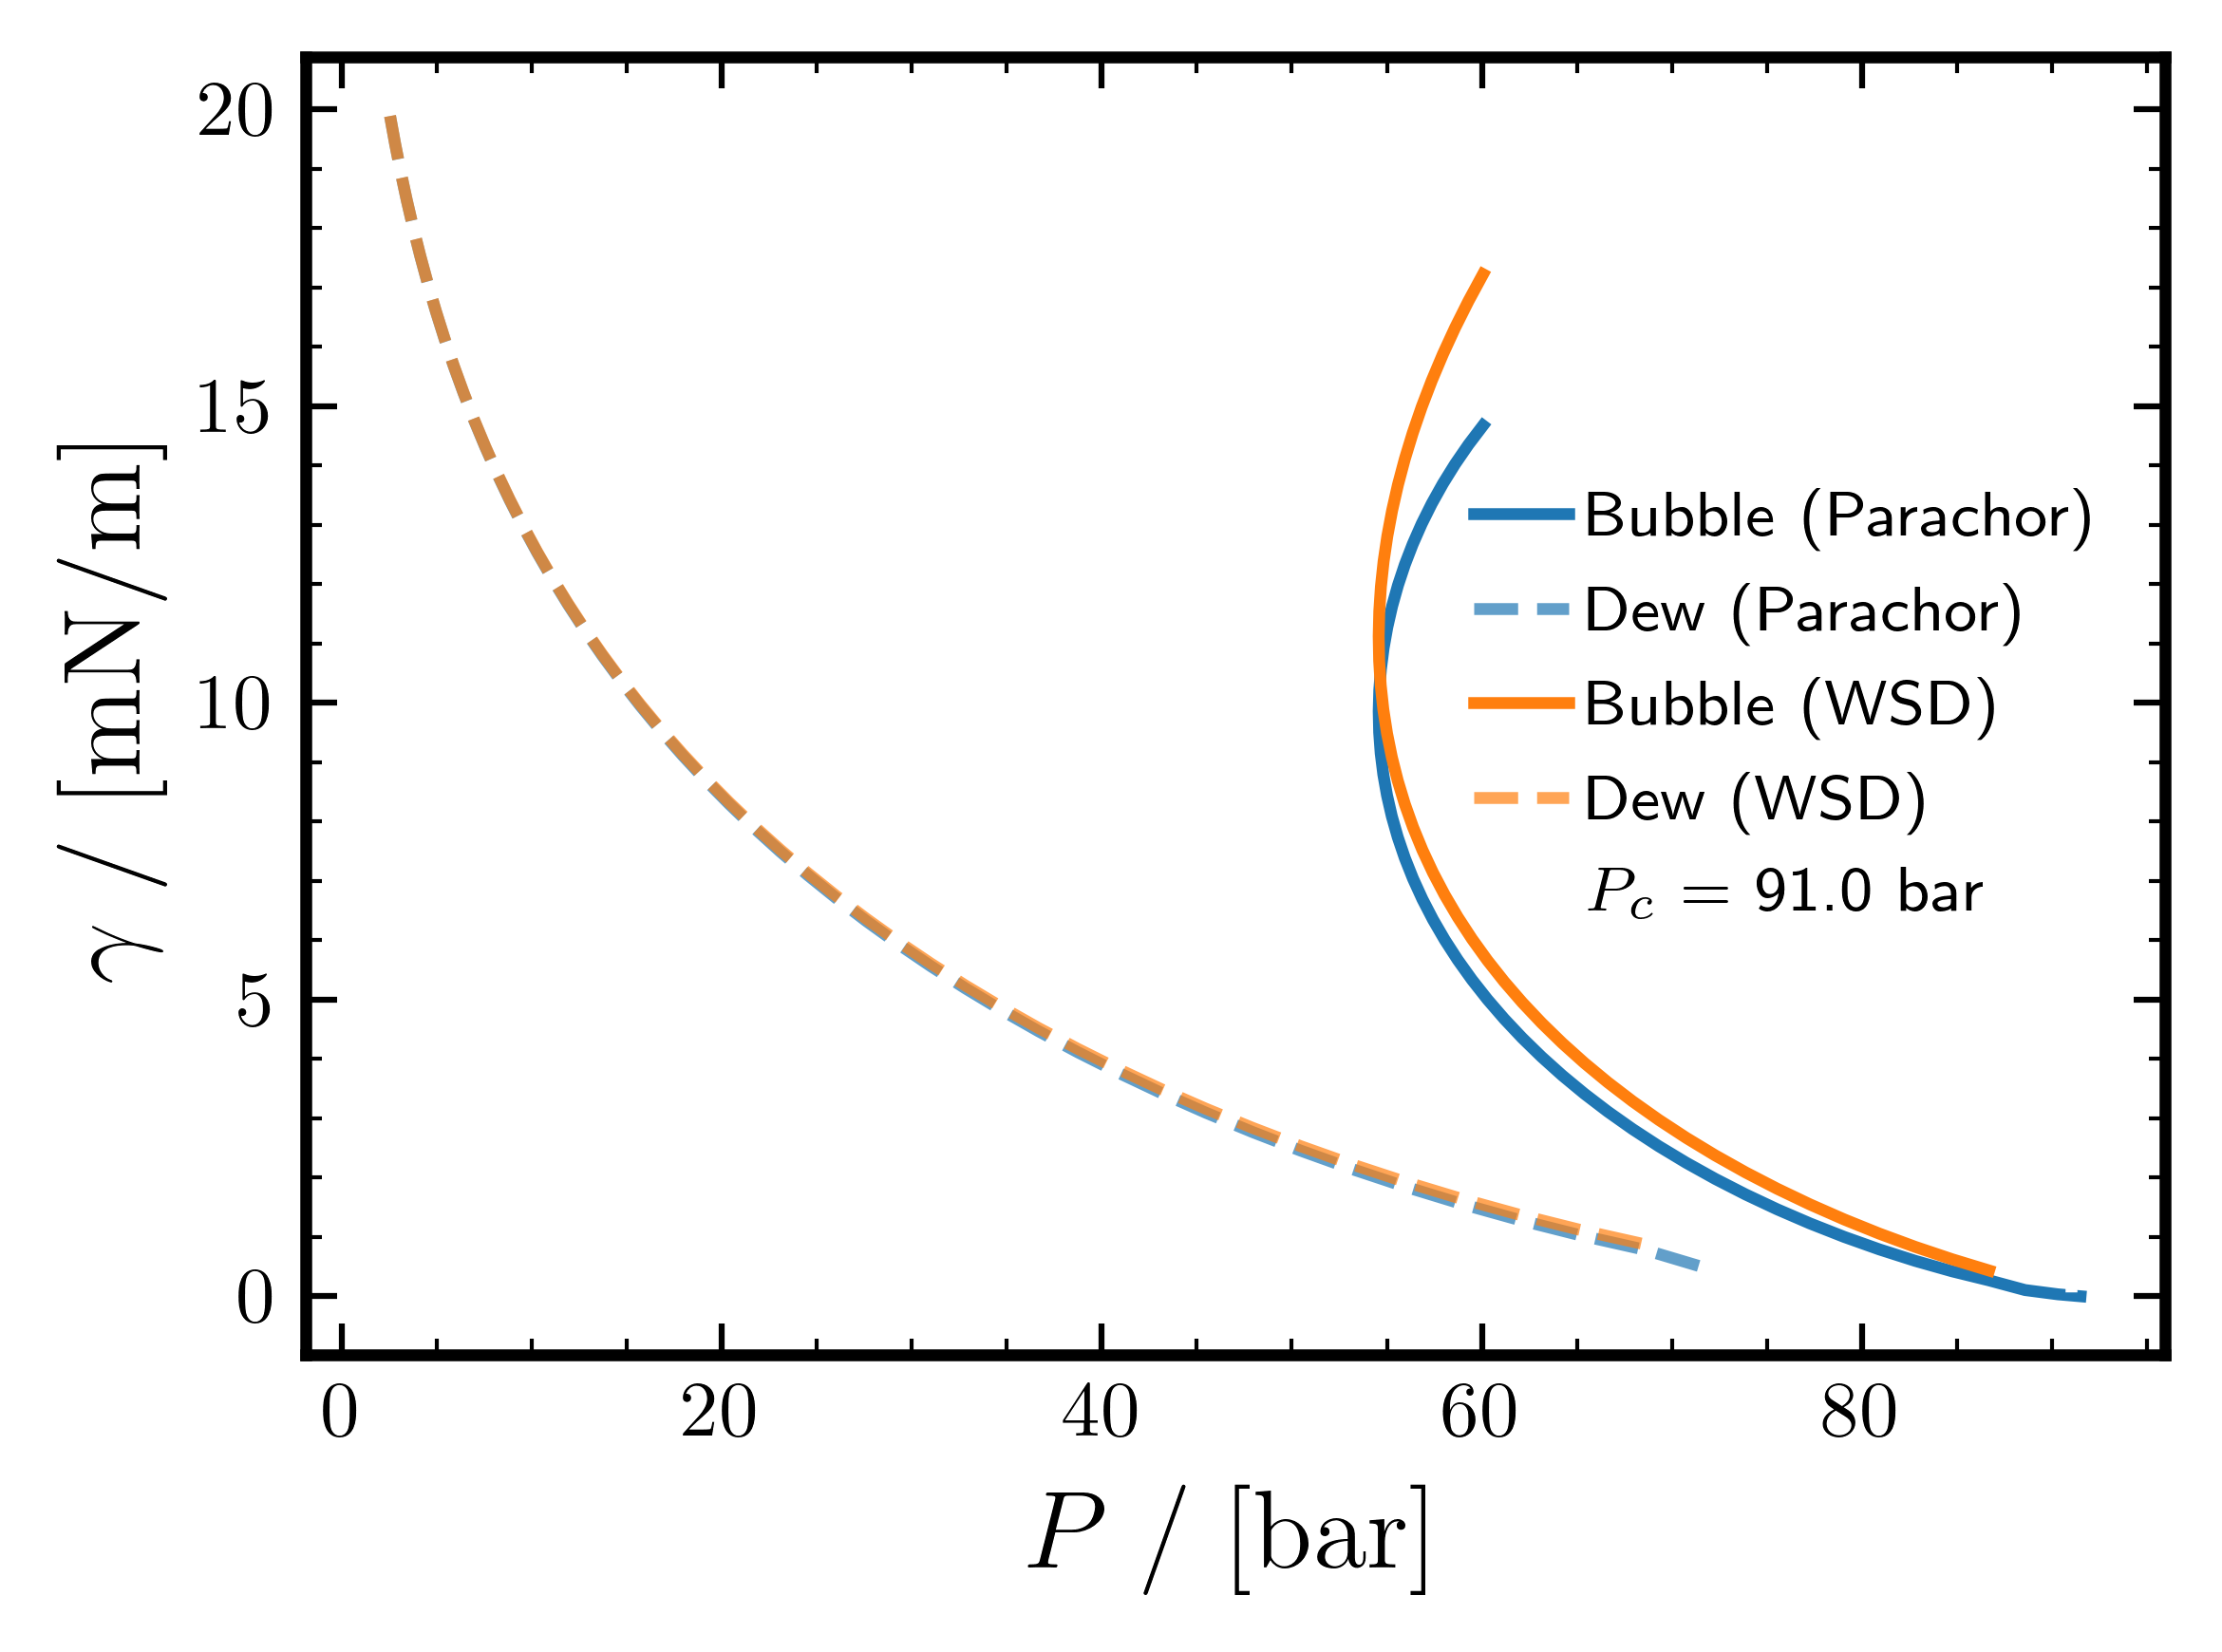

In [17]:
# --- Plot 2: IFT vs Pressure ---
if df_sat_parachor.empty and df_sat_wsd.empty:
    print("No data available - both DataFrames are empty")
else:
    fig, ax = ps.plot_init()

    if bub_para is not None and not bub_para.empty:
        ax.plot(
            bub_para["P"], bub_para["gamma_mix"],
            "-", label="Bubble (Parachor)", color="C0"
        )

    if dew_para is not None and not dew_para.empty:
        ax.plot(
            dew_para["P"], dew_para["gamma_mix"],
            "--", label="Dew (Parachor)", color="C0", alpha=0.7
        )

    if bub_wsd is not None and not bub_wsd.empty:
        ax.plot(
            bub_wsd["P"], bub_wsd["gamma_mix"],
            "-", label="Bubble (WSD)", color="C1"
        )

    if dew_wsd is not None and not dew_wsd.empty:
        ax.plot(
            dew_wsd["P"], dew_wsd["gamma_mix"],
            "--", label="Dew (WSD)", color="C1", alpha=0.7
        )

    ax.axvline(Pc_bar, color="w", linestyle=":", label=f"$P_c$ = {Pc_bar:.1f} bar")
    ax.set_xlabel(r"$P \; / \; [\mathrm{bar}]$", fontsize=ps.label_fontsize)
    ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
    ax.minorticks_on()
    ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
    plt.tight_layout()
    plt.show()

In [7]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 0.65 minutes
